# 18: FD001 LGBM final search and robustness

Este notebook usa solo validacion artificial. El test oficial FD001 no se utiliza.

Objetivo: comparar de forma acotada dos familias de LightGBM con `window_size=50` y `rul_cap=125`, sin elegir automaticamente un modelo final.

## Familias comparadas

- Familia A: `objective=regression` con `sample_weight_scheme=bin_weights`.
- Familia B: `objective=quantile`, `alpha in [0.35, 0.40, 0.45]`, sin sample weights.

No se prueban nuevas ventanas, nuevos caps, MLP, RandomForest, Ridge, XGB ni quantile con pesos.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'CMAPSSData').exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

import sys
sys.path.append(str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / 'results' / 'FD001'
FIGURES_DIR = PROJECT_ROOT / 'figures' / 'fd001_lgbm_final_search'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
WINDOW_SIZE = 50
RUL_CAP = 125
CUT_RULS = (20, 50, 80, 110, 140)
ROBUSTNESS_STATES = [0, 1, 2, 3, 4]
DANGEROUS_ERROR_THRESHOLD = 20

sns.set_theme(style='whitegrid')


In [2]:
try:
    import lightgbm  # noqa: F401
except ImportError as exc:
    raise ImportError('Esta busqueda requiere LightGBM instalado. No se reemplaza por otro modelo.') from exc

from src.preprocessed_FD001 import prepare_fd001_temporal_validation_only
from src.fd001_experiment_utils import (
    evaluate_lgbm_search_config,
    make_lgbm_search_configs,
    select_lgbm_robustness_candidates,
    summarize_lgbm_robustness,
)


## Etapa 1: busqueda fina en un split

In [3]:
prepared = prepare_fd001_temporal_validation_only(
    data_dir=PROJECT_ROOT / 'CMAPSSData',
    eval_size=0.2,
    random_state=RANDOM_STATE,
    max_rul=RUL_CAP,
    cut_ruls=CUT_RULS,
    window_size=WINDOW_SIZE,
)
prepared = dict(prepared)
prepared['y_train'] = prepared['y_train_raw'].clip(upper=RUL_CAP).copy()

print('train/eval:', prepared['X_train'].shape, prepared['X_eval'].shape)
print('features:', len(prepared['feature_columns']))


train/eval: (16561, 119) (99, 119)
features: 119


In [4]:
search_configs = make_lgbm_search_configs(
    n_family_a=30,
    n_family_b=30,
    random_state=RANDOM_STATE,
    quantile_alphas=(0.35, 0.40, 0.45),
)
print('configs:', len(search_configs))
pd.Series([config['family'] for config in search_configs]).value_counts()


configs: 60


A_regression_bin_weights    30
B_quantile_no_weights       30
Name: count, dtype: int64

In [5]:
search_rows = []
for idx, config in enumerate(search_configs, start=1):
    print(f"[{idx:02d}/{len(search_configs):02d}] {config['candidate_label']}")
    row = evaluate_lgbm_search_config(
        prepared,
        config,
        random_state=RANDOM_STATE,
        window_size=WINDOW_SIZE,
        rul_cap=RUL_CAP,
    )
    search_rows.append(row)

hyper_search = pd.DataFrame(search_rows).sort_values(['cmapss_score', 'rmse']).reset_index(drop=True)
hyper_search.to_csv(RESULTS_DIR / 'fd001_lgbm_final_hyper_search.csv', index=False)
display(hyper_search[[
    'candidate_label', 'family', 'objective', 'alpha', 'sample_weight_scheme',
    'mae', 'rmse', 'r2', 'cmapss_score', 'cmapss_score_mean',
    'dangerous_error_pct', 'conservative_error_pct', 'bias_mean'
]].head(10))


[01/60] A_regression_bin_weights_search_00


[02/60] A_regression_bin_weights_search_01


[03/60] A_regression_bin_weights_search_02


[04/60] A_regression_bin_weights_search_03


[05/60] A_regression_bin_weights_search_04


...

[57/60] B_quantile_a045_search_26


[58/60] B_quantile_a045_search_27


[59/60] B_quantile_a045_search_28


[60/60] B_quantile_a045_search_29


,candidate_label,family,objective,alpha,sample_weight_scheme,mae,rmse,r2,cmapss_score,cmapss_score_mean,dangerous_error_pct,conservative_error_pct,bias_mean
0,A_regression_bin_weights_search_08,A_regression_bin_weights,regression,NaN,bin_weights,10.766191,13.815804,0.892853,231.225708,2.335613,4.040404,16.161616,-2.579335
1,A_regression_bin_weights_search_16,A_regression_bin_weights,regression,NaN,bin_weights,10.508592,13.647184,0.895453,235.005680,2.373795,4.040404,14.141414,-2.335058
2,A_regression_bin_weights_search_25,A_regression_bin_weights,regression,NaN,bin_weights,10.435428,13.575715,0.896545,235.231671,2.376077,7.070707,13.131313,-1.919102
3,A_regression_bin_weights_search_20,A_regression_bin_weights,regression,NaN,bin_weights,10.679249,13.769039,0.893578,235.242146,2.376183,4.040404,11.111111,-2.522172
4,A_regression_bin_weights_search_11,A_regression_bin_weights,regression,NaN,bin_weights,10.602684,13.674617,0.895032,235.273775,2.376503,6.060606,12.121212,-2.511482
5,A_regression_bin_weights_search_14,A_regression_bin_weights,regression,NaN,bin_weights,10.826358,13.901421,0.891521,236.790016,2.391818,5.050505,13.131313,-2.693338
6,A_regression_bin_weights_search_12,A_regression_bin_weights,regression,NaN,bin_weights,10.658863,13.788119,0.893282,237.975915,2.403797,6.060606,13.131313,-2.143150
7,A_regression_bin_weights_search_00,A_regression_bin_weights,regression,NaN,bin_weights,10.789488,13.851249,0.892303,240.213029,2.426394,6.060606,12.121212,-2.243900
8,A_regression_bin_weights_search_18,A_regression_bin_weights,regression,NaN,bin_weights,10.702358,13.827470,0.892672,241.148475,2.435843,8.080808,14.141414,-1.938383
9,A_regression_bin_weights_search_28,A_regression_bin_weights,regression,NaN,bin_weights,10.816121,13.938415,0.890943,241.870035,2.443132,8.080808,15.151515,-2.345330


## Visuales de la busqueda

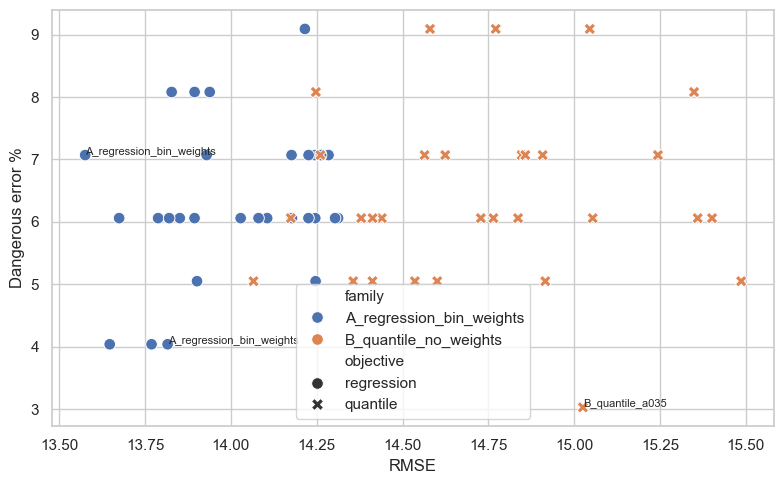

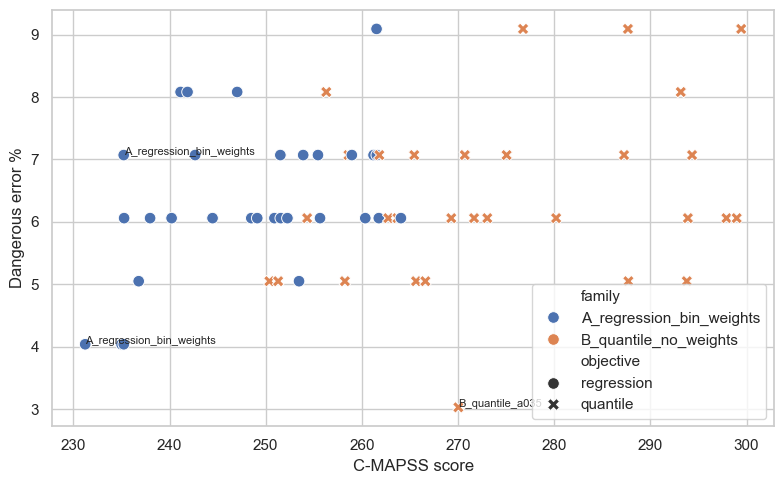

In [6]:
best_labels = set()
best_labels.add(hyper_search.sort_values('cmapss_score').iloc[0]['candidate_label'])
best_labels.add(hyper_search.sort_values('rmse').iloc[0]['candidate_label'])
best_labels.add(hyper_search.sort_values(['dangerous_error_pct', 'rmse']).iloc[0]['candidate_label'])
hyper_search['is_selected_for_label'] = hyper_search['candidate_label'].isin(best_labels)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=hyper_search, x='rmse', y='dangerous_error_pct', hue='family', style='objective', s=70)
for _, row in hyper_search.loc[hyper_search['is_selected_for_label']].iterrows():
    plt.annotate(row['candidate_label'].split('_search_')[0], (row['rmse'], row['dangerous_error_pct']), fontsize=8)
plt.xlabel('RMSE')
plt.ylabel('Dangerous error %')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'hyper_search_rmse_vs_dangerous.png', dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=hyper_search, x='cmapss_score', y='dangerous_error_pct', hue='family', style='objective', s=70)
for _, row in hyper_search.loc[hyper_search['is_selected_for_label']].iterrows():
    plt.annotate(row['candidate_label'].split('_search_')[0], (row['cmapss_score'], row['dangerous_error_pct']), fontsize=8)
plt.xlabel('C-MAPSS score')
plt.ylabel('Dangerous error %')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'hyper_search_cmapss_vs_dangerous.png', dpi=150)
plt.show()
plt.close()


## Etapa 2: robustez de candidatos

In [7]:
robustness_candidates = select_lgbm_robustness_candidates(hyper_search)
candidate_table = pd.DataFrame([
    {
        'candidate_label': config['candidate_label'],
        'family': config['family'],
        'objective': config['objective'],
        'alpha': config['alpha'],
        'sample_weight_scheme': config['sample_weight_scheme'],
        'params': config['params'],
    }
    for config in robustness_candidates
])
display(candidate_table)


,candidate_label,family,objective,alpha,sample_weight_scheme,params
0,candidate_00_A_regression_bin_weights_search_08,A_regression_bin_weights,regression,NaN,bin_weights,"{'colsample_bytree': 0.9, 'learning_rate': 0.0..."
1,candidate_01_A_regression_bin_weights_search_25,A_regression_bin_weights,regression,NaN,bin_weights,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
2,candidate_02_B_quantile_a035_search_02,B_quantile_no_weights,quantile,0.35,none,"{'colsample_bytree': 0.9, 'learning_rate': 0.0..."
3,candidate_03_B_quantile_a040_search_14,B_quantile_no_weights,quantile,0.40,none,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
4,candidate_04_base_regression_bin_weights,A_regression_bin_weights,regression,NaN,bin_weights,"{'learning_rate': 0.035, 'n_estimators': 220, ..."


In [8]:
robustness_rows = []
for state in ROBUSTNESS_STATES:
    print(f'Split random_state={state}')
    split_prepared = prepare_fd001_temporal_validation_only(
        data_dir=PROJECT_ROOT / 'CMAPSSData',
        eval_size=0.2,
        random_state=state,
        max_rul=RUL_CAP,
        cut_ruls=CUT_RULS,
        window_size=WINDOW_SIZE,
    )
    split_prepared = dict(split_prepared)
    split_prepared['y_train'] = split_prepared['y_train_raw'].clip(upper=RUL_CAP).copy()
    for config in robustness_candidates:
        row = evaluate_lgbm_search_config(
            split_prepared,
            config,
            random_state=state,
            window_size=WINDOW_SIZE,
            rul_cap=RUL_CAP,
        )
        robustness_rows.append(row)

robustness = pd.DataFrame(robustness_rows)
robustness.to_csv(RESULTS_DIR / 'fd001_lgbm_final_candidate_robustness.csv', index=False)
robustness_summary = summarize_lgbm_robustness(robustness)
robustness_summary.to_csv(RESULTS_DIR / 'fd001_lgbm_final_candidate_robustness_summary.csv', index=False)
display(robustness_summary[[
    'candidate_label', 'family', 'objective', 'alpha',
    'mean_rmse', 'std_rmse', 'mean_cmapss_score', 'std_cmapss_score',
    'mean_dangerous_error_pct', 'std_dangerous_error_pct',
    'worst_rmse', 'worst_cmapss_score', 'worst_dangerous_error_pct'
]])


Split random_state=0


Split random_state=1


Split random_state=2


Split random_state=3


Split random_state=4


,candidate_label,family,objective,alpha,mean_rmse,std_rmse,mean_cmapss_score,std_cmapss_score,mean_dangerous_error_pct,std_dangerous_error_pct,worst_rmse,worst_cmapss_score,worst_dangerous_error_pct
0,candidate_03_B_quantile_a040_search_14,B_quantile_no_weights,quantile,0.40,15.087995,1.383842,307.444648,86.612616,5.044692,3.649322,16.925379,398.125028,10.101010
1,candidate_02_B_quantile_a035_search_02,B_quantile_no_weights,quantile,0.35,15.471575,1.056115,314.736394,68.547850,4.840610,3.602211,16.769125,387.737736,10.101010
2,candidate_04_base_regression_bin_weights,A_regression_bin_weights,regression,NaN,15.024597,1.710580,323.526383,109.356231,4.638631,2.910961,17.057215,449.002082,7.070707
3,candidate_00_A_regression_bin_weights_search_08,A_regression_bin_weights,regression,NaN,15.148102,1.948642,328.319251,125.974816,6.248773,2.992280,17.326856,482.217878,10.101010
4,candidate_01_A_regression_bin_weights_search_25,A_regression_bin_weights,regression,NaN,15.105782,1.825031,331.068140,116.129751,5.046712,4.571506,17.198913,460.317434,11.111111


## Visuales de robustez

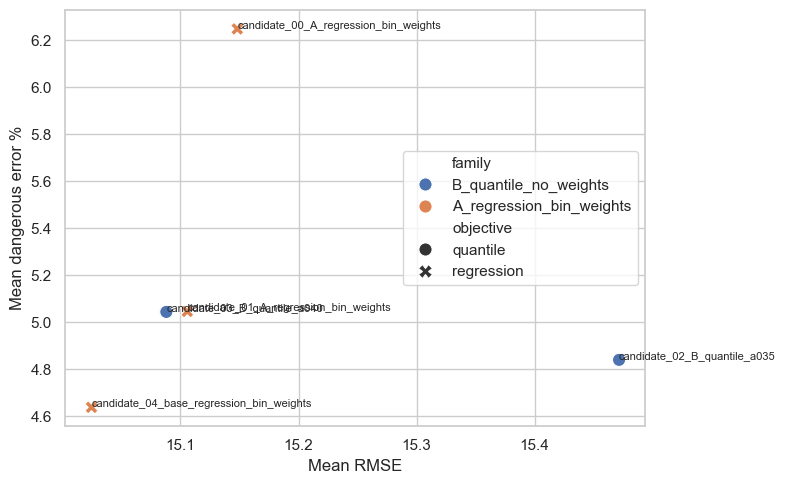

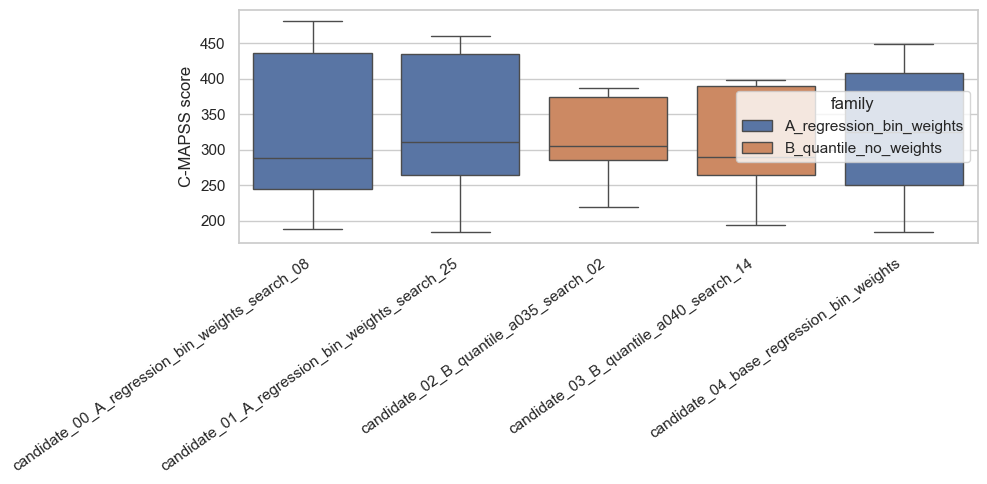

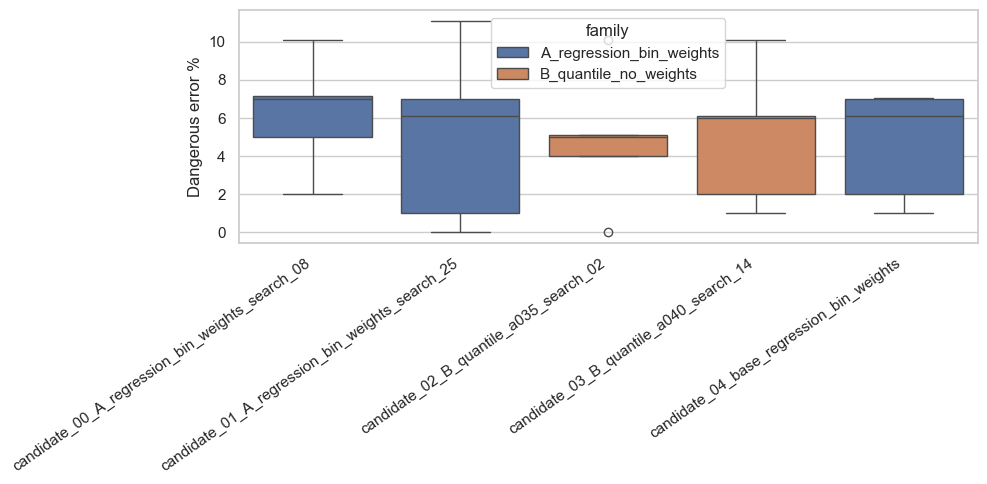

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=robustness_summary,
    x='mean_rmse',
    y='mean_dangerous_error_pct',
    hue='family',
    style='objective',
    s=90,
)
for _, row in robustness_summary.iterrows():
    plt.annotate(row['candidate_label'].split('_search_')[0], (row['mean_rmse'], row['mean_dangerous_error_pct']), fontsize=8)
plt.xlabel('Mean RMSE')
plt.ylabel('Mean dangerous error %')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'robustness_mean_rmse_vs_mean_dangerous.png', dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(10, 5))
sns.boxplot(data=robustness, x='candidate_label', y='cmapss_score', hue='family')
plt.xticks(rotation=35, ha='right')
plt.xlabel('')
plt.ylabel('C-MAPSS score')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'robustness_cmapss_distribution.png', dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(10, 5))
sns.boxplot(data=robustness, x='candidate_label', y='dangerous_error_pct', hue='family')
plt.xticks(rotation=35, ha='right')
plt.xlabel('')
plt.ylabel('Dangerous error %')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'robustness_dangerous_distribution.png', dpi=150)
plt.show()
plt.close()


## Cierre

- Se compararon LGBM regression + bin_weights contra LGBM quantile sin pesos.
- La busqueda se realizo con `window_size=50` y `rul_cap=125`.
- En el split base, las mejores configuraciones por C-MAPSS quedaron en la familia A regression + bin_weights.
- En robustez multi-split, los candidatos quantile quedaron competitivos: `quantile alpha=0.40` tuvo el menor C-MAPSS medio entre los candidatos robustos, mientras que el modelo base regression + bin_weights mantuvo el menor dangerous error medio.
- La etapa de robustez evalua candidatos en varios splits de motores y muestra que la decision depende del trade-off entre C-MAPSS, RMSE y dangerous error.
- La decision final queda pendiente de revisar la tabla de resultados.
- El test oficial FD001 no se uso.